In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
excel_file = "/content/partpdf_1772778998739_partpdf_1763620928546_netflix_titles.xlsx"

In [58]:
data = pd.read_excel(excel_file, sheet_name=None)

In [59]:
print("Available sheets:", list(data.keys()))


Available sheets: ['netflix_titles', 'netflix_titles_directors', 'netflix_titles_countries', 'netflix_titles_cast', 'netflix_titles_category']


In [60]:
netflix_titles = data['netflix_titles']
netflix_titles_cast = data['netflix_titles_cast']
netflix_titles_directors = data['netflix_titles_directors']
netflix_titles_category = data['netflix_titles_category']
netflix_titles_countries = data['netflix_titles_countries']

In [61]:
print("\n--- Sheet Shapes ---")
print(f"netflix_titles: {netflix_titles.shape}")
print(f"netflix_titles_cast: {netflix_titles_cast.shape}")
print(f"netflix_titles_directors: {netflix_titles_directors.shape}")
print(f"netflix_titles_category: {netflix_titles_category.shape}")
print(f"netflix_titles_countries: {netflix_titles_countries.shape}")


--- Sheet Shapes ---
netflix_titles: (6236, 9)
netflix_titles_cast: (44311, 2)
netflix_titles_directors: (4852, 2)
netflix_titles_category: (13670, 2)
netflix_titles_countries: (7179, 2)


In [62]:
master_df = netflix_titles.copy()

In [63]:
cast_agg = netflix_titles_cast.groupby('show_id')['cast'].apply(lambda x: ', '.join(x.dropna().astype(str))).reset_index()
cast_agg.columns = ['show_id', 'cast_list']
master_df = master_df.merge(cast_agg, on='show_id', how='left')

In [64]:
directors_agg = netflix_titles_directors.groupby('show_id')['director'].apply(lambda x: ', '.join(x.dropna().astype(str))).reset_index()
directors_agg.columns = ['show_id', 'director_list']
master_df = master_df.merge(directors_agg, on='show_id', how='left')


In [65]:
category_agg = netflix_titles_category.groupby('show_id')['listed_in'].apply(lambda x: ', '.join(x.dropna().astype(str))).reset_index()
category_agg.columns = ['show_id', 'category_list']
master_df = master_df.merge(category_agg, on='show_id', how='left')

In [66]:
countries_agg = netflix_titles_countries.groupby('show_id')['country'].apply(lambda x: ', '.join(x.dropna().astype(str))).reset_index()
countries_agg.columns = ['show_id', 'country_list']
master_df = master_df.merge(countries_agg, on='show_id', how='left')

In [67]:
print(" Master DataFrame ")
print(f"Shape: {master_df.shape}")
print(master_df.head())
print("Columns:", master_df.columns.tolist())

 Master DataFrame 
Shape: (6236, 13)
  duration_minutes duration_seasons     type  \
0               90              NaN    Movie   
1               94              NaN    Movie   
2              NaN                1  TV Show   
3              NaN                1  TV Show   
4               99              NaN    Movie   

                                     title           date_added  release_year  \
0  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   
1               Jandino: Whatever it Takes  2016-09-09 00:00:00        2016.0   
2                       Transformers Prime  2018-09-08 00:00:00        2013.0   
3         Transformers: Robots in Disguise  2018-09-08 00:00:00        2016.0   
4                             #realityhigh  2017-09-08 00:00:00        2017.0   

     rating                                        description     show_id  \
0     TV-PG  Before planning an awesome wedding for his gra...  81145628.0   
1     TV-MA  Jandino Asporaat r

here i used left join because it keep all the title from the master_df.

In [95]:
master_df['date_added'] = pd.to_datetime(master_df['date_added'], format='%B %d, %Y', errors='coerce')

/tmp/ipykernel_541/4202420554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df['date_added'] = pd.to_datetime(master_df['date_added'], format='%B %d, %Y', errors='coerce')


In [97]:
master_df['year_added'] = master_df['date_added'].dt.year

/tmp/ipykernel_541/3914899296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df['year_added'] = master_df['date_added'].dt.year


In [96]:
master_df

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast_list,director_list,category_list,country_list
0,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","Children & Family Movies, Comedies","United States, China, India, South Korea"
1,94,1,Movie,Jandino: Whatever it Takes,2016-09-09,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,"Raúl Campos, Jan Suter",Stand-Up Comedy,United Kingdom
2,90,1,TV Show,Transformers Prime,2018-09-08,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...","Raúl Campos, Jan Suter",Kids' TV,United States
3,90,1,TV Show,Transformers: Robots in Disguise,2018-09-08,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...","Raúl Campos, Jan Suter",Kids' TV,United States
4,99,1,Movie,#realityhigh,2017-09-08,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,Comedies,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6220,90,2,TV Show,Talking Tom and Friends,2019-04-10,2017.0,TV-G,Full of funny one-liners and always ready for ...,80162994.0,"Colin Hanks, Maria Bamford, Tom Kenny, James A...","Raúl Campos, Jan Suter","Kids' TV, TV Comedies","Cyprus, Austria, Thailand"
6221,90,2,TV Show,Pokémon the Series,2019-04-01,2019.0,TV-Y7-FV,Ash and his Pikachu travel to the Alola region...,80186475.0,"Sarah Natochenny, Alyson Leigh Rosenfeld, Rodg...","Raúl Campos, Jan Suter","Anime Series, Kids' TV",Japan
6222,90,2,TV Show,Justin Time,2016-04-01,2012.0,TV-Y,"In Justin's dreams, he and his imaginary frien...",70272742.0,"Gage Munroe, Scott McCord, Jenna Warren","Raúl Campos, Jan Suter",Kids' TV,Canada
6223,90,2,TV Show,Terrace House: Boys & Girls in the City,2016-04-01,2016.0,TV-14,A new set of six men and women start their liv...,80067942.0,"You, Azusa Babazono, Kentaro, Ayumu Mochizuki,...","Raúl Campos, Jan Suter","International TV Shows, Reality TV",Japan


In [69]:
master_df.isnull().sum()

,0
duration_minutes,1969
duration_seasons,4265
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4
cast_list,573


In [74]:
master_df["duration_minutes"] = master_df["duration_minutes"].fillna(master_df["duration_minutes"].mode()[0])

In [75]:
master_df["duration_seasons"] = master_df["duration_seasons"].fillna(master_df["duration_seasons"].mode()[0])

In [82]:
columns_to_check = ['show_id', 'title', 'type', 'date_added']
master_df= master_df.dropna(subset=columns_to_check)

In [92]:
master_df["cast_list"] = master_df["cast_list"].fillna("unknown")

/tmp/ipykernel_541/4206716935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df["cast_list"] = master_df["cast_list"].fillna("unknown")


In [93]:
master_df["director_list"] = master_df["director_list"].fillna("unknown")

/tmp/ipykernel_541/2140266324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df["director_list"] = master_df["director_list"].fillna("unknown")


In [94]:
master_df["country_list"] = master_df["country_list"].fillna("unknown")

/tmp/ipykernel_541/3424445449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df["country_list"] = master_df["country_list"].fillna("unknown")


In [91]:
master_df.isnull().sum()

,0
duration_minutes,0
duration_seasons,0
type,0
title,0
date_added,0
release_year,0
rating,9
description,0
show_id,0
cast_list,0


here i used mode for duration_minutes,duration_seasons because it is string so we can't fill with median and mostly are numebers so i used this. and in show_id,title,type,date_added here i used dropna because there is only few are missing like only 2,3 from 6236.then for country_list,director_list,cast_list for this i used unknown beacuse it indicates info that they can or cant't use.

In [98]:
df_cast_list_exploded = master_df.copy()

In [99]:
df_cast_list_exploded['cast'] = df_cast_list_exploded['cast_list'].str.split(', ')
df_cast_list_exploded = df_cast_list_exploded.explode('cast')

In [100]:
unique_cast = df_cast_list_exploded['cast'].nunique()
print(f"Total unique cast members: {unique_cast}")

Total unique cast members: 27367


In [103]:
print(f" Top 20 Most Frequent Cast Members")
cast_counts = df_cast_list_exploded['cast'].value_counts().head(20)
print(cast_counts)

 Top 20 Most Frequent Cast Members
cast
David Attenborough    586
Anupam Kher            33
Shah Rukh Khan         30
Om Puri                27
Naseeruddin Shah       27
Yuki Kaji              26
Akshay Kumar           26
Paresh Rawal           25
Takahiro Sakurai       25
Amitabh Bachchan       24
Boman Irani            23
Andrea Libman          22
Ashleigh Ball          22
John Cleese            22
Kareena Kapoor         19
Tara Strong            18
Vincent Tong           18
Daisuke Ono            18
Kay Kay Menon          18
Gulshan Grover         18
Name: count, dtype: int64


In [105]:
top_actor = cast_counts.idxmax()
top_actor_count = cast_counts.max()
print(f"Most frequent actor: {top_actor} (appears in {top_actor_count} shows)")

Most frequent actor: David Attenborough (appears in 586 shows)


so here i took cast_list and here i got david attenborough as most frequent actor came.so here i split it with comma and explode.here explode used because each member will get its own row then i done count unique member.

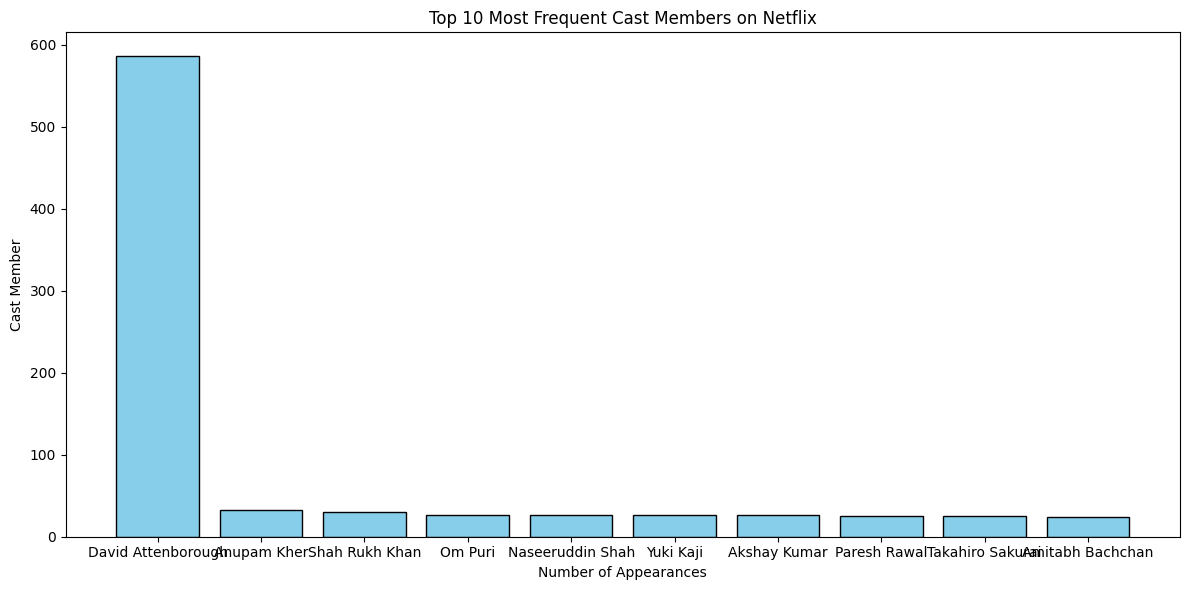

In [108]:
top_10_cast = df_cast_list_exploded['cast'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_cast.index, top_10_cast.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Appearances')
plt.ylabel('Cast Member')
plt.title('Top 10 Most Frequent Cast Members on Netflix')
plt.tight_layout()
plt.savefig('top_10_cast.png', dpi=300)
plt.show()

In [ ]:
here i done bar plot for cast list and its showing the most frequent cast.here content based so drama and triller genes are catalog

In [109]:
master_df.to_csv('netflix_cleaned_data.csv', index=False)
print("Cleaned data saved as 'netflix_cleaned_data.csv'")

print(f"\nDataset shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(master_df.head())

Cleaned data saved as 'netflix_cleaned_data.csv'

Dataset shape: (6221, 14)
Columns: ['duration_minutes', 'duration_seasons', 'type', 'title', 'date_added', 'release_year', 'rating', 'description', 'show_id', 'cast_list', 'director_list', 'category_list', 'country_list', 'year_added']

First few rows:
  duration_minutes duration_seasons     type  \
0               90                1    Movie   
1               94                1    Movie   
2               90                1  TV Show   
3               90                1  TV Show   
4               99                1    Movie   

                                     title date_added  release_year    rating  \
0  Norm of the North: King Sized Adventure 2019-09-09        2019.0     TV-PG   
1               Jandino: Whatever it Takes 2016-09-09        2016.0     TV-MA   
2                       Transformers Prime 2018-09-08        2013.0  TV-Y7-FV   
3         Transformers: Robots in Disguise 2018-09-08        2016.0     TV-Y7   
4  